In [239]:
story = "John, who had scheduled a meeting for Monday at 10:00 AM, packed his travel essentials carefully: a camera, sunglasses, three T-shirts, four pairs of jeans, a raincoat, snacks, water bottles, a map, travel tickets, a guidebook, a charger, and toiletries. He planned to discuss the concert tickets during the meeting, which he had bought for $50 each, and confirm his hotel booking for three nights in Tokyo, where the weather was forecasted to be sunny. With his flight departing at 7:30 PM tomorrow, John also made sure to pack a notebook, his phone, extra shoes, and a first-aid kit. The package for the event materials, which included banners, flyers, promotional T-shirts, and badges, was expected to arrive on June 15th, just before the project’s deadline next Friday. After everything was set, John sent an email to his manager confirming the event schedule at Central Park this evening, ensuring every detail from catering, stage setup, sound system, lighting, to guest seating arrangements was properly handled."


def sent_tokenization(texts: str) -> list[str]:
    sentence = []
    temp_word = ""
    in_list = False

    for i, letter in enumerate(texts):
        if letter == ",":
            if in_list:
                temp_word += letter
            else:
                temp_word += ","
        elif letter in ".?!":
            temp_word += letter
            sentence.append(temp_word.strip())
            temp_word = ""
            in_list = False
        else:
            temp_word += letter

            if i > 0 and texts[i - 1] == " and ":
                in_list = True
    return sentence


sentences = sent_tokenization(story)
sentences

['John, who had scheduled a meeting for Monday at 10:00 AM, packed his travel essentials carefully: a camera, sunglasses, three T-shirts, four pairs of jeans, a raincoat, snacks, water bottles, a map, travel tickets, a guidebook, a charger, and toiletries.',
 'He planned to discuss the concert tickets during the meeting, which he had bought for $50 each, and confirm his hotel booking for three nights in Tokyo, where the weather was forecasted to be sunny.',
 'With his flight departing at 7:30 PM tomorrow, John also made sure to pack a notebook, his phone, extra shoes, and a first-aid kit.',
 'The package for the event materials, which included banners, flyers, promotional T-shirts, and badges, was expected to arrive on June 15th, just before the project’s deadline next Friday.',
 'After everything was set, John sent an email to his manager confirming the event schedule at Central Park this evening, ensuring every detail from catering, stage setup, sound system, lighting, to guest seati

In [240]:
tokenized_word = [
    word.lower().strip(",.!?'\"")
    for sentence in sentences
    for word in sentence.split()
    if word not in [",", ".", "\"", "'", "?", "!", ": "]
]

tokenized_word

['john',
 'who',
 'had',
 'scheduled',
 'a',
 'meeting',
 'for',
 'monday',
 'at',
 '10:00',
 'am',
 'packed',
 'his',
 'travel',
 'essentials',
 'carefully:',
 'a',
 'camera',
 'sunglasses',
 'three',
 't-shirts',
 'four',
 'pairs',
 'of',
 'jeans',
 'a',
 'raincoat',
 'snacks',
 'water',
 'bottles',
 'a',
 'map',
 'travel',
 'tickets',
 'a',
 'guidebook',
 'a',
 'charger',
 'and',
 'toiletries',
 'he',
 'planned',
 'to',
 'discuss',
 'the',
 'concert',
 'tickets',
 'during',
 'the',
 'meeting',
 'which',
 'he',
 'had',
 'bought',
 'for',
 '$50',
 'each',
 'and',
 'confirm',
 'his',
 'hotel',
 'booking',
 'for',
 'three',
 'nights',
 'in',
 'tokyo',
 'where',
 'the',
 'weather',
 'was',
 'forecasted',
 'to',
 'be',
 'sunny',
 'with',
 'his',
 'flight',
 'departing',
 'at',
 '7:30',
 'pm',
 'tomorrow',
 'john',
 'also',
 'made',
 'sure',
 'to',
 'pack',
 'a',
 'notebook',
 'his',
 'phone',
 'extra',
 'shoes',
 'and',
 'a',
 'first-aid',
 'kit',
 'the',
 'package',
 'for',
 'the',
 'eve

### Building Word2Vec model

In [241]:
def mapping_word(tokens: list[str]) -> tuple[dict[str, int], dict[int, str]]:
    word_to_idx = {}
    idx_to_word = {}

    for i, word in enumerate(set(tokens)):
        word_to_idx[word] = i
        idx_to_word[i] = word

    return word_to_idx, idx_to_word

word_to_idx, idx_to_word = mapping_word(tokenized_word)

word_to_idx

{'phone': 0,
 'with': 1,
 'made': 2,
 'four': 3,
 'was': 4,
 'carefully:': 5,
 'an': 6,
 'confirm': 7,
 'pack': 8,
 'bottles': 9,
 'project’s': 10,
 'this': 11,
 'just': 12,
 'email': 13,
 'departing': 14,
 'evening': 15,
 'lighting': 16,
 'to': 17,
 'before': 18,
 'schedule': 19,
 'every': 20,
 'jeans': 21,
 't-shirts': 22,
 'setup': 23,
 'in': 24,
 'pm': 25,
 'camera': 26,
 'sunny': 27,
 'be': 28,
 'also': 29,
 'nights': 30,
 'map': 31,
 'central': 32,
 'john': 33,
 'the': 34,
 'scheduled': 35,
 'concert': 36,
 'bought': 37,
 'each': 38,
 'shoes': 39,
 '10:00': 40,
 'sunglasses': 41,
 'system': 42,
 'monday': 43,
 'event': 44,
 'expected': 45,
 'set': 46,
 'promotional': 47,
 'forecasted': 48,
 'sent': 49,
 'next': 50,
 'tickets': 51,
 'water': 52,
 'during': 53,
 'package': 54,
 'banners': 55,
 'arrangements': 56,
 'tokyo': 57,
 'properly': 58,
 'meeting': 59,
 'notebook': 60,
 'confirming': 61,
 'packed': 62,
 'three': 63,
 'charger': 64,
 'catering': 65,
 'he': 66,
 'a': 67,
 'pla

__Generating Training data__<br>
We have tokenized word, but token is still in the form of string, we need to encode them.<br>
We use one-hot vectorization. We also need to generate a bundle on input and target values.<br>

In [277]:
import numpy as np

np.random.seed(42)

def concat(*iterables):
    for iterable in iterables:
        yield from iterable

def one_hot_encoding(idx, vocab_size):
    res = [0] * vocab_size
    res[idx] = 1
    return res

def generate_training_data(tokens, word_to_id, window):
    X = []
    y = []
    n_tokens = len(tokens)

    for i in range(n_tokens):
        idx = concat(
            range(max(0, i - window), i),
            range(i, min(n_tokens, i + window + 1))
        )

        for j in idx:
            if i == j:
                continue
            X.append(one_hot_encoding(word_to_id[tokens[i]], len(word_to_id)))
            y.append(one_hot_encoding(word_to_id[tokens[j]], len(word_to_id)))

    return np.asarray(X), np.asarray(y)

X, y = generate_training_data(tokenized_word, word_to_idx, 3)

In [243]:
print(f"X: {X.shape}")
print(f"y: {y.shape}")

X: (972, 120)
y: (972, 120)


__Make Forward Propagation__

A1 = X•W1 <br>
A2 = A1•W2 <br>
Z = softmax(A2)

In [244]:
def init_network(vocab_size, n_embedding):
    model = {
        "w1": np.random.rand(vocab_size, n_embedding),
        "w2": np.random.rand(n_embedding, vocab_size),
    }

    return model

def softmax(X):
    res = []
    for x in X:
        exp = np.exp(x)
        res.append(exp / exp.sum())
    return res

def forward(model, X, return_cache = True):
    cache = {}

    cache["a1"] = X @ model["w1"]
    cache["a2"] = cache["a1"] @ model["w2"]
    cache["z"] = softmax(cache["a2"])

    if not return_cache:
        return cache["z"]

    return cache

In [245]:
model = init_network(len(word_to_idx), n_embedding=15)

(X @ model["w1"]).shape

(972, 15)

In [246]:
(X @ model["w1"] @ model["w2"]).shape

(972, 120)

__Make Back Propagation__

DA2 = Z - y <br>
DW2 = A1.T • DA2 <br>
DA1 = DA2 • W2.T <br>
DW1 = X.T • DA1 <br>
W1 = W1 - (alpha • DW1) <br>
W2 = W2 - (alpha • DW2) <br>
BP = - sigma log(z) • y

In [247]:
def cross_entropy(z, y):
    return - np.sum(np.log(z) * y)

def backward(model, X, y, alpha):
    cache = forward(model, X)
    da2 = cache["z"] - y
    dw2 = cache["a1"].T @ da2
    da1 = da2 @ model["w2"].T
    dw1 = X.T @ da1
    assert(dw2.shape == model["w2"].shape)
    assert(dw1.shape == model["w1"].shape)
    model["w1"] -= alpha * dw1
    model["w2"] -= alpha * dw2
    return cross_entropy(cache["z"], y)

__Model Testing__

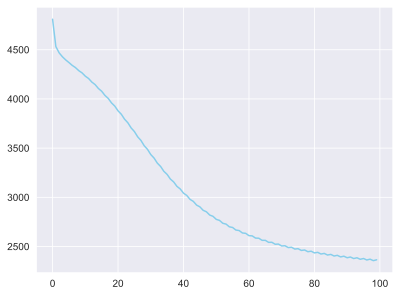

In [248]:
import matplotlib.pyplot as plt

n_iter = 100
learning_rate = 0.012

history = [backward(model, X, y, learning_rate) for _ in range(n_iter)]
plt.plot(range(len(history)), history, color="skyblue")
plt.show()

In [274]:
def get_nearest_word(model, word, top_word = 10):
    learning = one_hot_encoding(word_to_idx[word], len(word_to_idx))
    result = forward(model, [learning], return_cache=False)[0][:top_word]

    for word in (idx_to_word[id] for id in np.argsort(result)[::-1]):
        print(word)

get_nearest_word(model, "travel", 5)

phone
four
with
made
was


In [255]:
def get_embedding(model, word):
    try:
        idx = word_to_idx[word]
    except:
        print("Word is not in corpus")
    one_hot = one_hot_encoding(idx, len(word_to_idx))
    return forward(model, one_hot)["a1"]

get_embedding(model, "travel")

array([ 0.71763423, -0.19597369,  0.78580625,  0.17050355, -0.46910243,
        1.58178551,  0.20627028, -0.6334125 ,  0.34630319,  0.17385785,
        1.53937786,  0.12905007,  1.46682371,  0.24904684, -1.5694157 ])

### TF-IDF
Calculate Term Frequency (modus/len sentence)

In [340]:
def calc_term_frequency(sent: list[str]) -> list[dict]:
    tf = []
    for sentence in sent:
        words = sentence.lower().split()
        sent_len = len(words)
        unique_word = {}
        for word in words:
            unique_word[word] = unique_word.get(word, 0) + 1 / sent_len
        tf.append(unique_word)
    return tf

tf = calc_term_frequency(sentences)
tf

[{'john,': 0.025,
  'who': 0.025,
  'had': 0.025,
  'scheduled': 0.025,
  'a': 0.15,
  'meeting': 0.025,
  'for': 0.025,
  'monday': 0.025,
  'at': 0.025,
  '10:00': 0.025,
  'am,': 0.025,
  'packed': 0.025,
  'his': 0.025,
  'travel': 0.05,
  'essentials': 0.025,
  'carefully:': 0.025,
  'camera,': 0.025,
  'sunglasses,': 0.025,
  'three': 0.025,
  't-shirts,': 0.025,
  'four': 0.025,
  'pairs': 0.025,
  'of': 0.025,
  'jeans,': 0.025,
  'raincoat,': 0.025,
  'snacks,': 0.025,
  'water': 0.025,
  'bottles,': 0.025,
  'map,': 0.025,
  'tickets,': 0.025,
  'guidebook,': 0.025,
  'charger,': 0.025,
  'and': 0.025,
  'toiletries.': 0.025},
 {'he': 0.05714285714285714,
  'planned': 0.02857142857142857,
  'to': 0.05714285714285714,
  'discuss': 0.02857142857142857,
  'the': 0.08571428571428572,
  'concert': 0.02857142857142857,
  'tickets': 0.02857142857142857,
  'during': 0.02857142857142857,
  'meeting,': 0.02857142857142857,
  'which': 0.02857142857142857,
  'had': 0.02857142857142857,
 

__Calculate Document Frequency__

In [341]:
def calc_document_frequency(sent: list[str])-> dict:
    word_collection = {}
    for sentence in sent:
        words = set(sentence.lower().split())
        for word in words:
            word_collection[word] = word_collection.get(word, 0) + 1
    return word_collection

df = calc_document_frequency(sentences)
df

{'snacks,': 1,
 'john,': 1,
 'meeting': 1,
 'packed': 1,
 'three': 2,
 'his': 4,
 'scheduled': 1,
 't-shirts,': 2,
 'four': 1,
 'a': 2,
 'charger,': 1,
 'who': 1,
 '10:00': 1,
 'carefully:': 1,
 'tickets,': 1,
 'camera,': 1,
 'monday': 1,
 'essentials': 1,
 'had': 2,
 'jeans,': 1,
 'of': 1,
 'at': 3,
 'guidebook,': 1,
 'raincoat,': 1,
 'pairs': 1,
 'sunglasses,': 1,
 'and': 4,
 'travel': 1,
 'water': 1,
 'map,': 1,
 'toiletries.': 1,
 'for': 3,
 'bottles,': 1,
 'am,': 1,
 'where': 1,
 'the': 3,
 'concert': 1,
 'which': 2,
 'he': 1,
 'bought': 1,
 'meeting,': 1,
 'planned': 1,
 'was': 3,
 'discuss': 1,
 'confirm': 1,
 'sunny.': 1,
 'tokyo,': 1,
 'to': 4,
 'each,': 1,
 'forecasted': 1,
 'tickets': 1,
 'weather': 1,
 'in': 1,
 'during': 1,
 'hotel': 1,
 'booking': 1,
 '$50': 1,
 'be': 1,
 'nights': 1,
 'john': 2,
 'kit.': 1,
 'shoes,': 1,
 'with': 1,
 'made': 1,
 'phone,': 1,
 'first-aid': 1,
 'tomorrow,': 1,
 'pack': 1,
 'sure': 1,
 'departing': 1,
 'extra': 1,
 'pm': 1,
 '7:30': 1,
 'al

__Calculate Inverse Document Frequency__

In [345]:
def calc_inverse_document_frequency(sent: list[str], document_frequency: dict)-> dict:
    idf = {}
    num_col = len(sent)
    for word, df in document_frequency.items():
        idf[word] = np.log(num_col / df)
    return idf

idf = calc_inverse_document_frequency(sentences, df)
idf

{'snacks,': 1.6094379124341003,
 'john,': 1.6094379124341003,
 'meeting': 1.6094379124341003,
 'packed': 1.6094379124341003,
 'three': 0.9162907318741551,
 'his': 0.22314355131420976,
 'scheduled': 1.6094379124341003,
 't-shirts,': 0.9162907318741551,
 'four': 1.6094379124341003,
 'a': 0.9162907318741551,
 'charger,': 1.6094379124341003,
 'who': 1.6094379124341003,
 '10:00': 1.6094379124341003,
 'carefully:': 1.6094379124341003,
 'tickets,': 1.6094379124341003,
 'camera,': 1.6094379124341003,
 'monday': 1.6094379124341003,
 'essentials': 1.6094379124341003,
 'had': 0.9162907318741551,
 'jeans,': 1.6094379124341003,
 'of': 1.6094379124341003,
 'at': 0.5108256237659907,
 'guidebook,': 1.6094379124341003,
 'raincoat,': 1.6094379124341003,
 'pairs': 1.6094379124341003,
 'sunglasses,': 1.6094379124341003,
 'and': 0.22314355131420976,
 'travel': 1.6094379124341003,
 'water': 1.6094379124341003,
 'map,': 1.6094379124341003,
 'toiletries.': 1.6094379124341003,
 'for': 0.5108256237659907,
 'bot

In [352]:
def calc_tf_idf(term_frequency: list[dict], inverse_document_frequency: dict)-> dict:
    tf_idf_list = []
    for tf_dict in term_frequency:
        tf_idf_dict = {}
        for word, tf_val in tf_dict.items():
            tf_idf_dict[word] = tf_val * inverse_document_frequency.get(word, 0)
        tf_idf_list.append(tf_idf_dict)
    return tf_idf_list

tf_idf = calc_tf_idf(tf, idf)
tf_idf

[{'john,': 0.04023594781085251,
  'who': 0.04023594781085251,
  'had': 0.02290726829685388,
  'scheduled': 0.04023594781085251,
  'a': 0.13744360978112327,
  'meeting': 0.04023594781085251,
  'for': 0.012770640594149769,
  'monday': 0.04023594781085251,
  'at': 0.012770640594149769,
  '10:00': 0.04023594781085251,
  'am,': 0.04023594781085251,
  'packed': 0.04023594781085251,
  'his': 0.005578588782855245,
  'travel': 0.08047189562170502,
  'essentials': 0.04023594781085251,
  'carefully:': 0.04023594781085251,
  'camera,': 0.04023594781085251,
  'sunglasses,': 0.04023594781085251,
  'three': 0.02290726829685388,
  't-shirts,': 0.02290726829685388,
  'four': 0.04023594781085251,
  'pairs': 0.04023594781085251,
  'of': 0.04023594781085251,
  'jeans,': 0.04023594781085251,
  'raincoat,': 0.04023594781085251,
  'snacks,': 0.04023594781085251,
  'water': 0.04023594781085251,
  'bottles,': 0.04023594781085251,
  'map,': 0.04023594781085251,
  'tickets,': 0.04023594781085251,
  'guidebook,':